In [ ]:
import qiskit
import qiskit_algorithms
import qiskit_optimization

from qiskit_aer import AerSimulator
from qiskit.primitives import Sampler
from qiskit_algorithms import QAOA, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams["figure.dpi"] = 1000
mpl.rcParams["savefig.dpi"] = 1000

import math
import contextlib
import io
import os

import sys
import os
# Add parent directory to path to import max_k_cut
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), '../..')))

from max_k_cut import (
    docplex_BQO, docplex_RBQO, docplex_QUBO, docplex_RQUBO,
    tight_qubo_penalty, tight_rqubo_penalty, naive_qubo_penalty, naive_rqubo_penalty,
    interpolated_qubo_penalty, interpolated_rqubo_penalty,
    generate_graph, plot_graph, feasibility_filter, expected_value, repenalize
)
from max_k_cut.qaoa import run_qaoa_extract_samples
from scripts.plot_histogram import plot_qaoa_histogram

# from qiskit_algorithms.utils import algorithm_globals
# algorithm_globals.random_seed = 123

import warnings
# Suppress specific DeprecationWarning
warnings.filterwarnings('ignore', category=DeprecationWarning)


print("qiskit version:",qiskit.__version__)
print("qiskit algorithms version:",qiskit_algorithms.__version__)
print("qiskit optimization version:",qiskit_optimization.__version__)

qiskit version: 1.3.2
qiskit algorithms version: 0.3.1
qiskit optimization version: 0.6.1


In [2]:
# Problem instance
K = 3

num_nodes = 5
edge_probability = 0.5
weighted = False
weight_range = 1

# parameters
backend = AerSimulator()
sampler = Sampler()
cvar_alpha = 1 # alpha for CVaR aggregation in (0,1], 1 for full distribution, 0 for only the best solution
shots = 1024/cvar_alpha
sampler.set_options(shots=shots, backend=backend)
optimizer = COBYLA()
reps = 1
initial_point = np.zeros(2 * reps)

# solvers
qaoa = QAOA(
    sampler=sampler, 
    optimizer=optimizer, 
    reps=reps, 
    initial_point=initial_point,
    aggregation=cvar_alpha
    )

np_solver = NumPyMinimumEigensolver() # exact classical solver
# create minimum eigen optimizer based on solver used
qaoa_optimizer = MinimumEigenOptimizer(qaoa)
np_optimizer = MinimumEigenOptimizer(np_solver)

bqo_max_val = 0
rbqo_max_val = 0

while bqo_max_val <= 1 or rbqo_max_val <= 1:
    G = generate_graph(num_nodes, edge_probability, weighted, weight_range)
    
    # BQO ========================================================
    dp_bqo = docplex_BQO(G, K, "Max-K-Cut")

    # R-BQO ========================================================
    dp_rbqo = docplex_RBQO(G, K, "Max-K-Cut")

    # Solve models and get objective values
    objective_values = {
        "BQO": dp_bqo.solve().objective_value,
        "RBQO": dp_rbqo.solve().objective_value
    }
    # Define a tolerance for the comparison
    tolerance = 1e-9
    # Assert that the objective values are close to each other
    bqo_value = objective_values["BQO"]
    for label, value in objective_values.items():
        assert math.isclose(bqo_value, value, abs_tol=tolerance), f"{label} value differs"
    MAX_FVAL = bqo_value

    with contextlib.redirect_stdout(io.StringIO()):
        # Run QAOA to extract raw samples for all models.
        results_dict = run_qaoa_extract_samples(
            [dp_bqo, dp_rbqo],
            ["BQO", "RBQO"],
            optimizer=qaoa_optimizer
        )

    bqo_samples = results_dict["BQO"]["samples"]
    bqo_max_val = max(sample.fval for sample in bqo_samples)
    print("bqo max val: ", bqo_max_val)

    rbqo_samples = results_dict["RBQO"]["samples"]
    rbqo_max_val = max(sample.fval for sample in rbqo_samples)
    print("rbqo max val: ", rbqo_max_val)

print("invalid reformulation found!")

bqo max val:  1.0
rbqo max val:  1.5
bqo max val:  1.0
rbqo max val:  1.5
bqo max val:  1.0
rbqo max val:  1.6666666666666667
bqo max val:  1.0
rbqo max val:  2.0
bqo max val:  1.0
rbqo max val:  1.6666666666666667
bqo max val:  1.0
rbqo max val:  1.1666666666666667
bqo max val:  1.0
rbqo max val:  1.6666666666666667
bqo max val:  1.0
rbqo max val:  1.6
bqo max val:  1.0
rbqo max val:  1.8
bqo max val:  1.0
rbqo max val:  2.0
bqo max val:  1.0
rbqo max val:  1.4
bqo max val:  1.0
rbqo max val:  2.0
bqo max val:  1.0
rbqo max val:  2.0
bqo max val:  1.0
rbqo max val:  1.6
bqo max val:  1.0
rbqo max val:  1.3333333333333333
bqo max val:  1.1666666666666667
rbqo max val:  1.3333333333333333
invalid reformulation found!


In [14]:
bqo_samples.sort(key=lambda x: x.fval, reverse=True)
print(bqo_samples[0])
print()
rbqo_samples.sort(key=lambda x: x.fval, reverse=True)
print(rbqo_samples[0])

SolutionSample(x=array([0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1.]), fval=1.1666666666666667, probability=0.0009765625, status=<OptimizationResultStatus.INFEASIBLE: 2>)

SolutionSample(x=array([0., 0., 0., 0., 1., 1., 0., 0., 0., 0.]), fval=1.3333333333333333, probability=0.0205078125, status=<OptimizationResultStatus.INFEASIBLE: 2>)


In [ ]:
from qiskit_optimization.translators import from_docplex_mp # creates QuadraticProgram from docplex model
# repenalize and feasibility_filter are already imported in cell 0
import numpy as np
import matplotlib.pyplot as plt

def plot_histogram(
    sample_results,
    *keys,
    Graph=None,
    Partitions=None,
    filter_infeasible=False,
    new_pen_list=None,
    bins='auto'
):
    """
    Plot a histogram of probability vs. approximation ratio for QAOA results using plt.hist.

    This function processes the raw QAOA samples by optionally re-penalizing and/or filtering them,
    then plots a histogram for each provided key in sample_results.

    If keys are provided (after sample_results), only those specified keys
    will be plotted. For example:
        plot_qaoa_histogram(results_dict, 'QUBO (Tight)', 'RQUBO (Tight)')

    Args:
        sample_results (dict): A dictionary where each key is a label and its value is a dict containing:
            - "samples": Raw QAOA samples.
            - "dp_model": The original docplex model.
        *keys (str): Optional keys specifying which results to plot.
        Graph (optional): Graph object for feasibility filtering.
        Partitions (optional): Partitions for feasibility filtering.
        filter_infeasible (bool, optional): If True, filter out infeasible solutions.
            Requires Graph and Partitions to be provided.
        new_pen_list (dict, optional): A dictionary mapping each label to a boolean indicating
            whether to re-penalize the samples. If None, defaults to all False.
        bins: Either an integer (or array of bin edges) or a string specifying the binning rule.
              If it's a string (e.g. 'auto'), we compute a common set of bin edges from all data.
        
    Returns:
        None
    """
    # If keys are provided, subset sample_results accordingly.
    if keys:
        sample_results = {k: sample_results[k] for k in keys if k in sample_results}
    
    # Set default re-penalization flags if not provided.
    if new_pen_list is None:
        new_pen_list = {label: False for label in sample_results}
    
    if filter_infeasible and (Graph is None or Partitions is None):
        raise ValueError("Graph and Partitions must be provided when filter_infeasible is True.")
    
    # # Mapping for re-penalization: keys match the label exactly.
    # repen_mapping = {
    #     "QUBO (Tight)": dp_qubo_naive,
    #     "QUBO (Naive)": dp_qubo_tight,
    #     "RQUBO (Tight)": dp_rqubo_naive,
    #     "RQUBO (Naive)": dp_rqubo_tight,
    # }

    # Prepare to collect data for all histograms (so we can compute common bin edges).
    processed_hist_data = []

    # Process each label (entry) in sample_results.
    for label, result in sample_results.items():
        samples = result["samples"]
        current_label = label
        
        # # If re-penalization is requested, look up this label in repen_mapping:
        # if new_pen_list.get(label, False):
        #     if label not in repen_mapping:
        #         raise ValueError(f"Label '{label}' not recognized for re-penalization mapping.")
        #     new_model = from_docplex_mp(repen_mapping[label])
        #     samples = repenalize(samples, new_model)
        #     current_label += " (Repenalized)"
        
        # Filter infeasible samples if requested.
        if filter_infeasible:
            samples, _ = feasibility_filter(Graph, Partitions, samples, current_label)
            # Normalize probabilities
            total_prob = sum(sample.probability for sample in samples)
            for sample in samples:
                sample.probability /= total_prob
            
        # Compute approximation ratios and probabilities for this dataset.
        approx_ratios = [sample.fval for sample in samples] #already normalized in previous function
        probs = [sample.probability for sample in samples]
        
        # Store them for plotting later (all at once).
        processed_hist_data.append((approx_ratios, probs, current_label))
    
    # If bins is a string (e.g. 'auto'), we compute a common set of bin edges
    # from all approximation ratio data so that every dataset uses the same bins.
    
    all_approx = []
    for approx_ratios, _, _ in processed_hist_data:
        all_approx.extend(approx_ratios)
    
    if isinstance(bins, str):
        bin_edges = np.histogram_bin_edges(all_approx, bins=bins)
    else:
        bin_edges = bins

    # Create the plot
    plt.figure(figsize=(8, 6))

    for approx_ratios, probs, current_label in processed_hist_data:
        n, bins, patches = plt.hist(
            approx_ratios,
            bins=bin_edges,
            weights=probs,
            alpha=0.35,
            label=current_label,
            histtype='stepfilled'
        )
        
        # Extract face color from the first patch
        color = patches[0].get_facecolor()
        
        # Compute the expected value
        exp_val = np.sum(np.array(approx_ratios) * np.array(probs))
        
        # # Plot a vertical line in that color
        # plt.vlines(
        #     exp_val, 0, 1, linestyles='dashed', color=color, lw=1,
        #     label=f"Expected Value of {current_label}: {exp_val:.2f}"
        # )

    plt.xlabel('Approximation Ratio')
    plt.ylabel('Probability')
    title = 'QAOA Distribution'
    if filter_infeasible:
        title += ' (Feasible Solutions Only)'
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

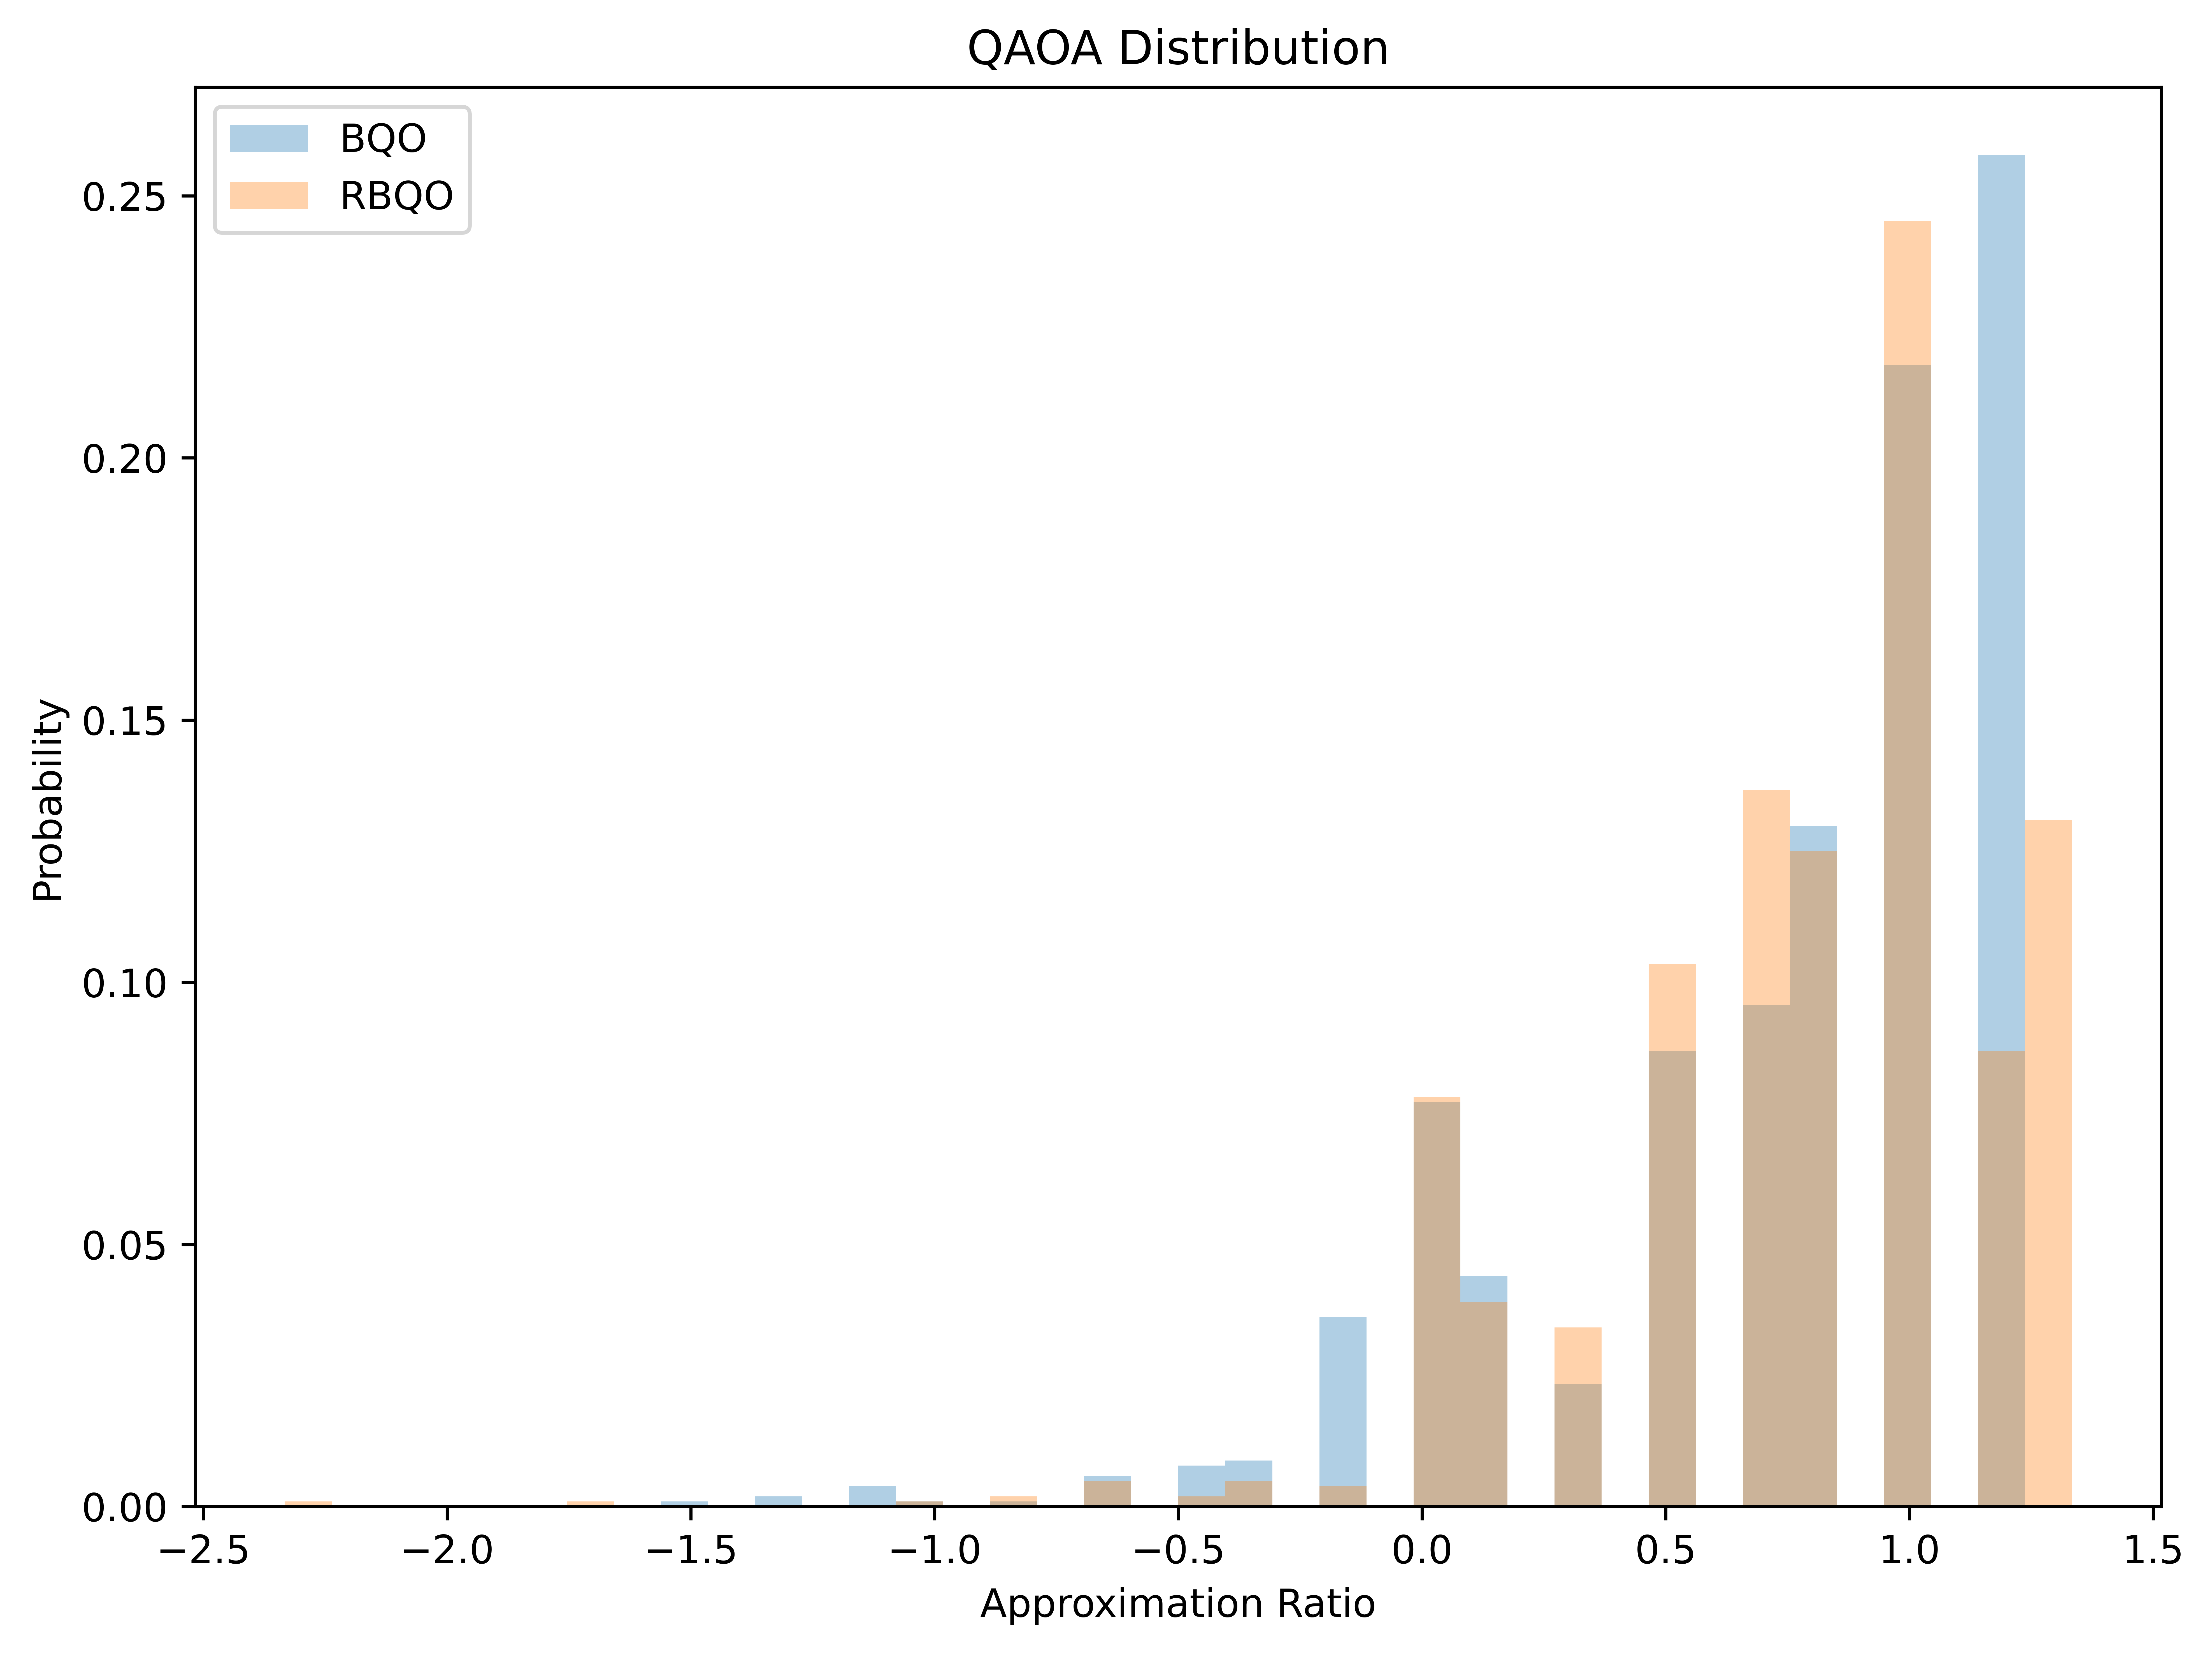

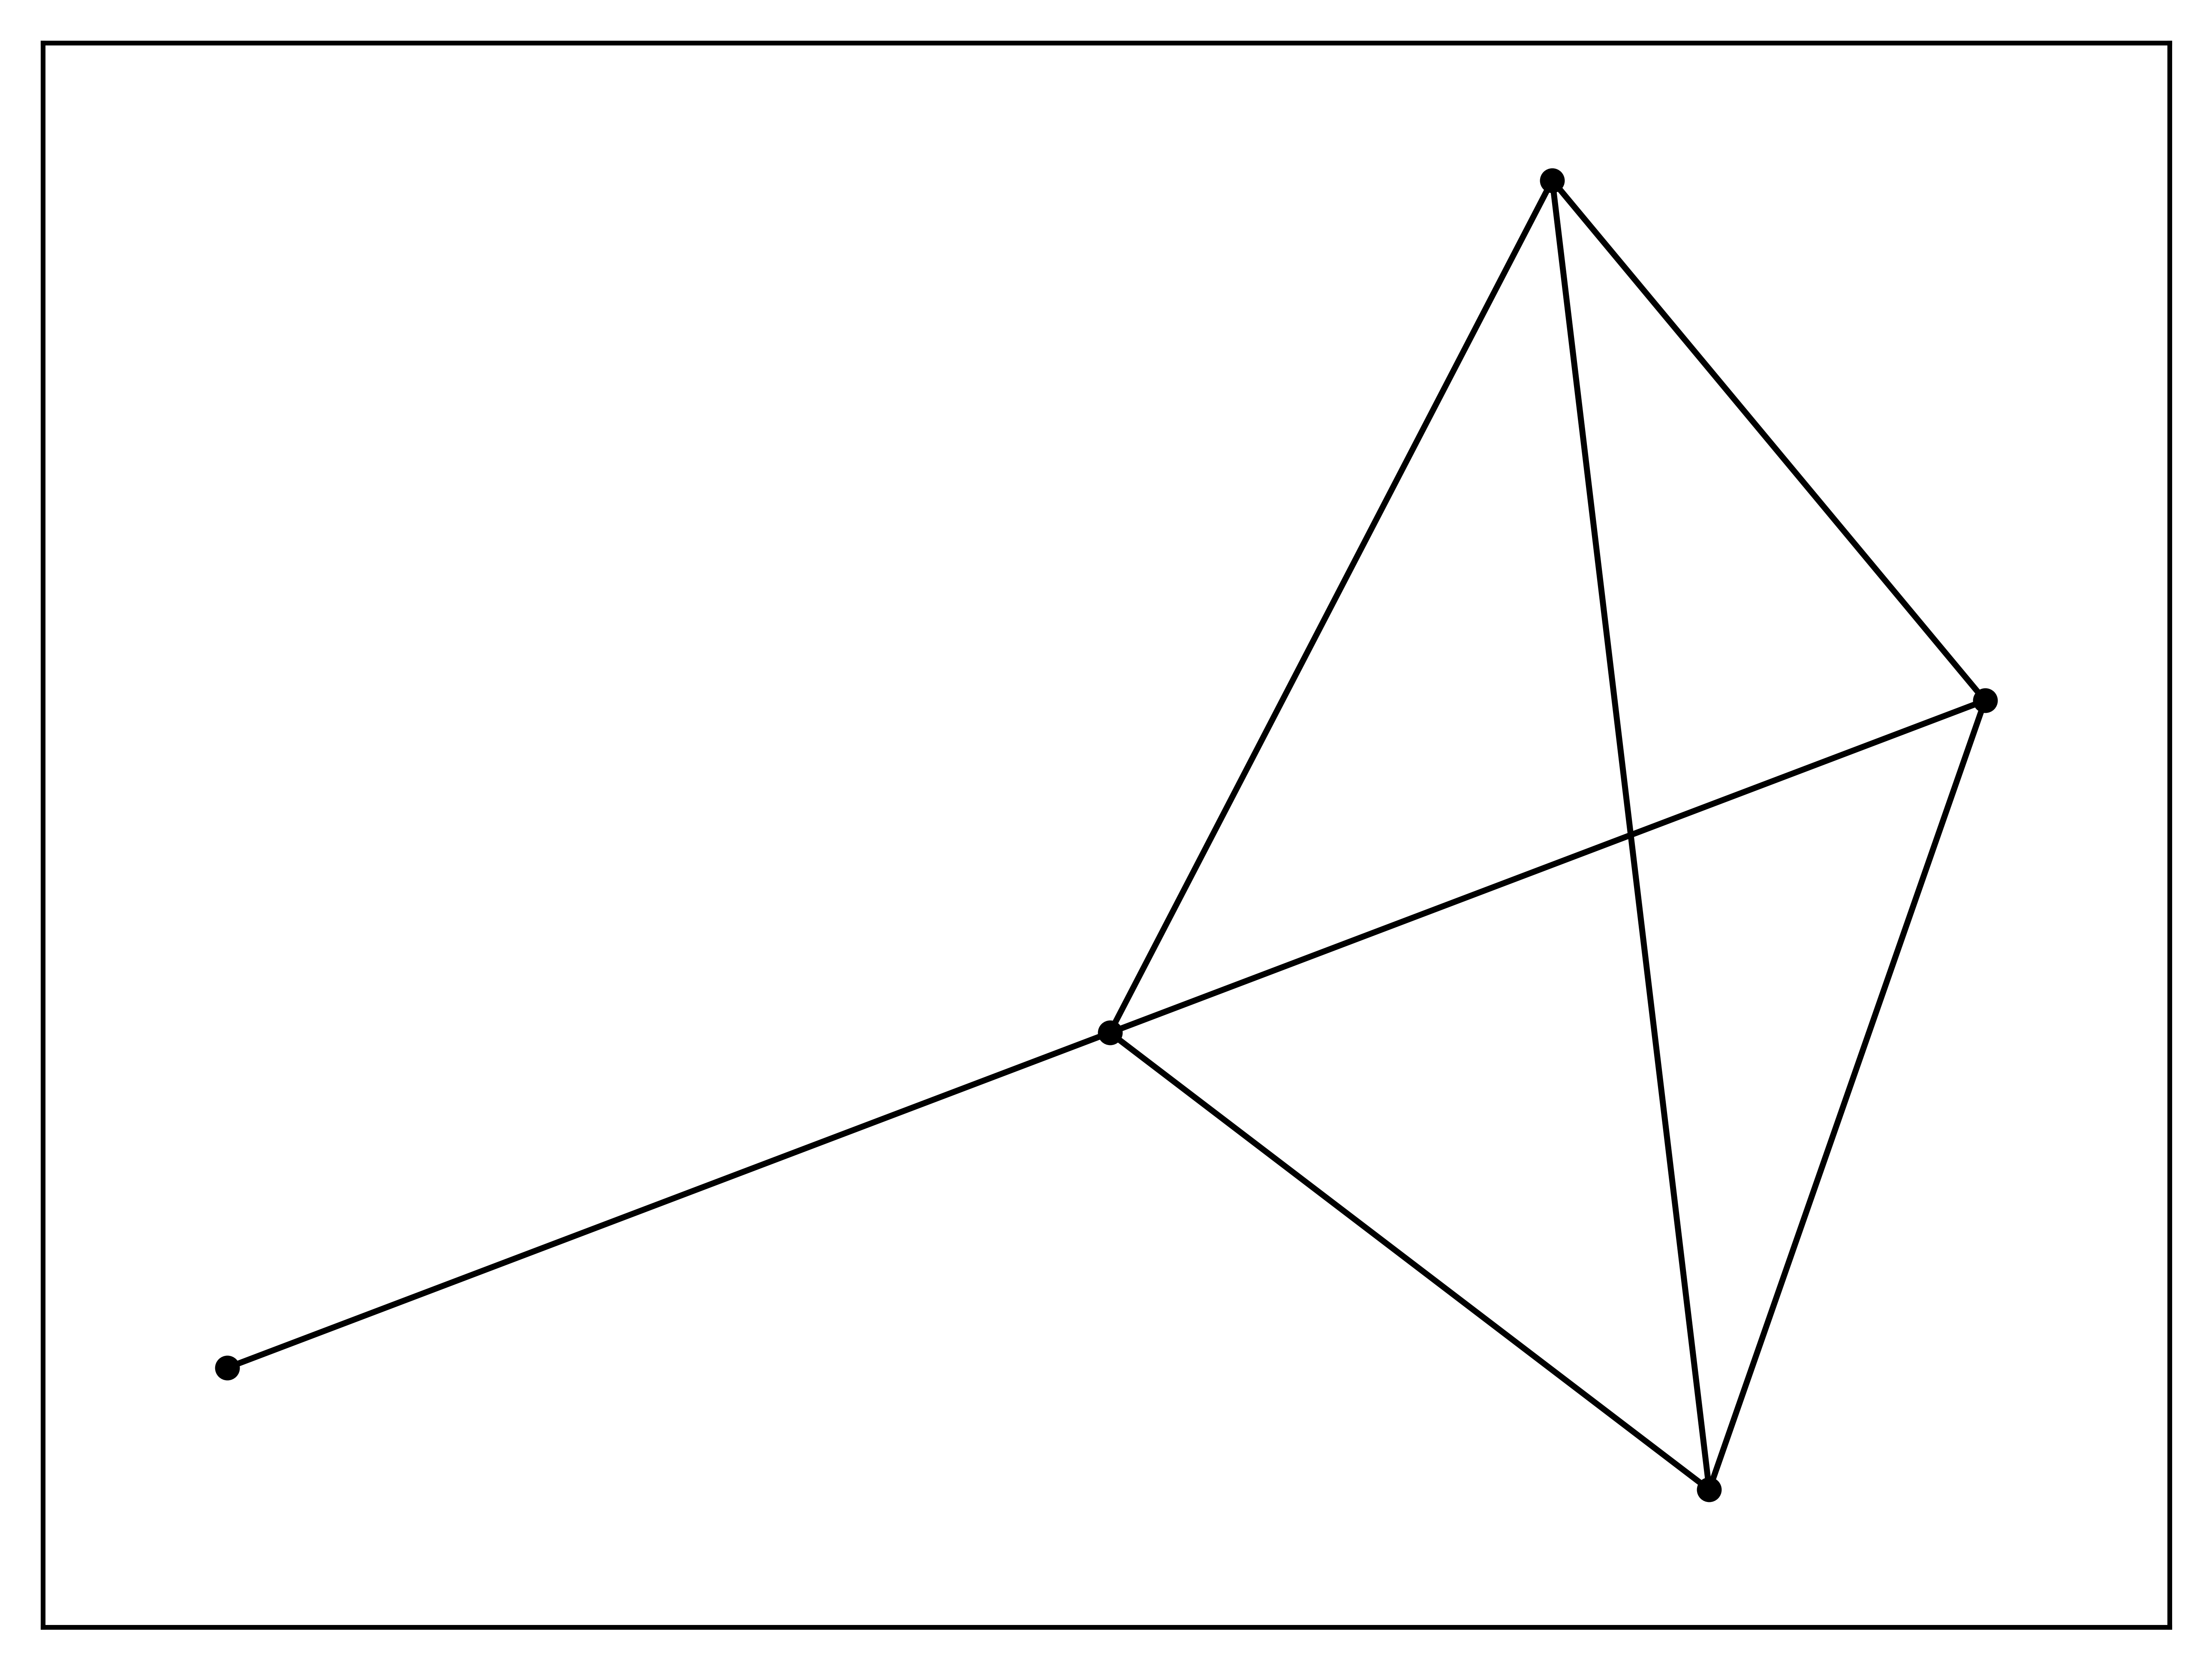

In [10]:
# Plot the histogram with default settings (no filtering, no re-penalization).
plot_histogram(results_dict, 'BQO', 'RBQO')

plot_graph(G)